<a href="https://colab.research.google.com/github/Meghnashankr23/3DVSS_June2026/blob/main/Photorealistic_Human_hands/Photorealistic_Human_hands.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**`PHOTOREALISTIC HAND AVATAR TEXTURING WITH PALMAR AND DORSAL HAND VIEWS `**

Photorealistic texturing of a 3D hand model requires strong semantic understanding of hand anatomy. Existing image-based texture generation methods often lack awareness of the structural differences between the palmar and dorsal sides of the hand, causing texture repetition, incorrect anatomical placement, and loss of contextual details.

To address this limitation, we employ a ControlNet-based texture generation framework conditioned on semantic maps, depth maps, and hand masks. These anatomical priors guide the diffusion process to generate semantically consistent and geometrically aligned hand textures. The generated textures are subsequently transferred to a UV texture image, which can be directly wrapped onto a standard 3D hand mesh.

****
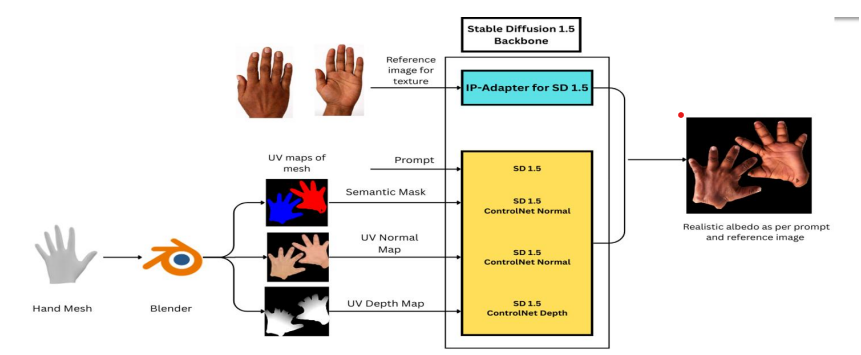
*Figure:Photorealistic Texture Generation Pipeline*

Unlike existing approaches that reconstruct a complete textured 3D hand and often require multi-view capture, optimization, and several hours of processing to achieve high-quality results, our method is lightweight and efficient. Given only a front (palmar) and back (dorsal) hand image, it generates a high-quality UV texture map in under one minute, enabling rapid creation of personalized photorealistic hand avatars for XR, gaming, telepresence, and digital human applications.

### Check Python Version
This cell checks the currently installed Python version in the Colab environment.

In [ ]:
! python --version

### Download Demo Assets
This cell downloads a `Demo.zip` file containing necessary assets for the project from a Google Drive link using `gdown`.

In [ ]:
import gdown
!gdown --folder 1O-1Zh_zNzTnIWGSH63urcTRr8_ER9uEj

### Install Required Libraries
This cell installs all the necessary Python libraries for the project, including `diffusers`, `PIL` (though it's usually `Pillow`), `numpy`, `ip-adapter`, and `opencv-python`.

In [ ]:
!pip install diffusers
!pip install PIL
!pip install numpy
!pip install ip-adapter
!pip install opencv-python

### Load and Display Control and Reference Images
This cell loads various control images (UV normal, depth, mask) and semantic UV maps, as well as reference images for the back and palm of the hand. It then displays these images using OpenCV.

Visualise the control inputs and the reference Dorsal and Palmar image for the model

In [ ]:
import torch
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
from diffusers import (
    StableDiffusionControlNetPipeline,
    ControlNetModel,
    DDIMScheduler
)
from ip_adapter import IPAdapter
import cv2
from google.colab.patches import cv2_imshow




# --------------------------------------------------
# CONFIG
# --------------------------------------------------
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
DTYPE  = torch.float16 # Changed to float16 to reduce memory usage on GPU

BASE_MODEL = "runwayml/stable-diffusion-v1-5"
CN_NORMAL  = "lllyasviel/control_v11p_sd15_normalbae"
CN_DEPTH   = "lllyasviel/control_v11f1p_sd15_depth"

# --------------------------------------------------
# LOAD UV MAPS
# --------------------------------------------------
def load_rgb(path): return Image.open(path).convert("RGB")
def load_gray(path): return Image.open(path).convert("L")

uv_normal = load_rgb("/content/colab_demo/uv_bakes_Mano_Right/control_uv_normal.png") # use control_uv_ring_normal for ring textures
uv_depth  = load_gray("/content/colab_demo/uv_bakes_Mano_Right/uv_depth.png")
uv_mask   = load_gray("/content/colab_demo/uv_bakes_Mano_Right/uv_mask.png")
print("\033[1m" + "CONTROL IMAGES-UV NORMAL, UV DEPTH, UV MASK" + "\033[0m")
hstitch=np.hstack((uv_normal, uv_depth.convert('RGB'), uv_mask.convert('RGB')))
hstitch_bgr = cv2.cvtColor(hstitch, cv2.COLOR_RGB2BGR)
cv2_imshow(np.array(hstitch_bgr))

# 🔴 NEW: semantic UV map
semantic_uv = load_rgb("/content/colab_demo/uv_bakes_Mano_Right/semantic_mask.png")

# 🔴 NEW: reference images per semantic region
ref_back = load_rgb("/content/colab_demo/dark_skin_back.png")
ref_palm = load_rgb("/content/colab_demo/dark_skin_palm.png")
print("\033[1m" + "DORSAL AND PALMAR IMAGES" + "\033[0m")
new_width = int(ref_back.width * ref_back.height / ref_palm.height)
ref_palm = ref_palm.resize((new_width, ref_back.height))

combined = np.concatenate([np.array(ref_back), np.array(ref_palm)], axis=1)

plt.figure(figsize=(12,6))
plt.imshow(combined)
plt.axis("off")
plt.show()


# ref_nail = load_rgb("input/ref_nail.png")  # optional

**Texture Generation with ControlNet**

Generate UV Texture using Stable diffusion conditioned on UV-Normal and UV-Depth separately for Frontal and Dorsal Images. Final Texture is obtained by merging both sides of the hand.

### Configure and Run Diffusion Process
This extensive cell performs several critical steps:
- Resizes UV maps to the target resolution.
- Creates semantic masks for palm and back regions.
- Loads ControlNet models for normal and depth guidance.
- Initializes the Stable Diffusion ControlNet Pipeline.
- Loads and configures the IP-Adapter for style conditioning.
- Sets up prompts for generating back and palm textures.
- Runs the diffusion process separately for the back and palm of the hand, applying masks.
- Composites the generated back and palm textures based on semantic masks to create a final UV albedo texture.
- Saves the final texture as `hand_albedo_uv.png`.

In [ ]:


W, H = (1024,1024) # For faster execution run wit h(768,768)

uv_normal = uv_normal.resize((W, H))
uv_depth   = uv_depth.resize((W, H))
uv_mask    = uv_mask.resize((W, H))
semantic_uv = semantic_uv.resize((W, H))

# depth must be RGB
uv_depth = Image.merge("RGB", (uv_depth, uv_depth, uv_depth))

# --------------------------------------------------
# SEMANTIC MASKS (KEY ADDITION)
# --------------------------------------------------
semantic_np = np.array(semantic_uv)

palm_mask   = (semantic_np[:,:,0] > 200) & (semantic_np[:,:,1] < 50)
back_mask   = (semantic_np[:,:,2] > 200)
#finger_mask = (semantic_np[:,:,1] > 200)
#nail_mask   = (semantic_np[:,:,0] > 200) & (semantic_np[:,:,1] > 200)

def mask_to_pil(mask):
    return Image.fromarray((mask * 255).astype(np.uint8))

palm_mask_img = mask_to_pil(palm_mask)
back_mask_img = mask_to_pil(back_mask)

# --------------------------------------------------
# CONTROLNETS
# --------------------------------------------------
controlnets = [
    ControlNetModel.from_pretrained(CN_NORMAL, torch_dtype=DTYPE),
    ControlNetModel.from_pretrained(CN_DEPTH,  torch_dtype=DTYPE),
]

pipe = StableDiffusionControlNetPipeline.from_pretrained(
    BASE_MODEL,
    controlnet=controlnets,
    torch_dtype=DTYPE,
    safety_checker=None
)

pipe.scheduler = DDIMScheduler.from_config(pipe.scheduler.config)
# Removed pipe.to(DEVICE) as it will be replaced by enable_model_cpu_offload()

# --------------------------------------------------
# IP-ADAPTER (STYLE ANCHOR)
# --------------------------------------------------
pipe.load_ip_adapter(
    "h94/IP-Adapter",
    subfolder="models",
    weight_name="ip-adapter-plus_sd15.bin"
)
pipe.set_ip_adapter_scale(0.6)

# Re-enabled pipe.enable_model_cpu_offload() and moved it after all components are loaded
pipe.enable_model_cpu_offload()

# --------------------------------------------------
# PROMPTS (SEMANTIC-AWARE)
# --------------------------------------------------

prompt_back = (
    "UV texture map of back of hand " # for ring texture add engagement ring in prompt
    "Bright Skin,fine hair"
)

prompt_palm = (
    "UV texture map of palm of hand" # for ring texture add engagement ring in prompt
    "Realistic Human palm texture "
)

negative_prompt = (
    "lighting, shadows, highlights, specular, "
    "photo, render, camera, depth, shading"
)

# --------------------------------------------------
# RUN DIFFUSION — BACK OF HAND
# --------------------------------------------------
with torch.autocast(DEVICE):
    back_result = pipe(
        prompt=prompt_back,
        #negative_prompt=negative_prompt,
        image=[uv_normal, uv_depth],
        ip_adapter_image=ref_back,
        controlnet_conditioning_scale=[0.9, 0.6],
        guidance_scale=7,
        num_inference_steps=20,
        width=W,
        height=H,
        mask_image=back_mask_img,
        denoising_start=0.15,
    ).images[0]

# --------------------------------------------------
# RUN DIFFUSION — PALM
# --------------------------------------------------
with torch.autocast(DEVICE):
    palm_result = pipe(
        prompt=prompt_palm,
        #negative_prompt=negative_prompt,
        image=[uv_normal, uv_depth],
        ip_adapter_image=ref_palm,
        controlnet_conditioning_scale=[0.9, 0.6],
        guidance_scale=7,
        num_inference_steps=18,
        width=W,
        height=H,
        mask_image=palm_mask_img,
        denoising_start=0.15,
    ).images[0]

# --------------------------------------------------
# COMPOSITE RESULTS BY SEMANTICS
# --------------------------------------------------
back_np = np.array(back_result,dtype=np.float32)
palm_np = np.array(palm_result,dtype=np.float32)
final_np = back_np.copy()

final_np[palm_mask] = palm_np[palm_mask]

# Apply global UV mask
uv_mask_np = np.array(uv_mask) / 255.0
final_np *= uv_mask_np[..., None]

final = Image.fromarray(final_np.astype(np.uint8))
final.save("/content/colab_demo/hand_albedo_uv.png")

print("✅ SEMANTIC-AWARE UV ALBEDO GENERATED")
import cv2
from google.colab.patches import cv2_imshow
output = cv2.imread('/content/colab_demo/hand_albedo_uv.png')

cv2_imshow(output)

### Texture Generation on New Pair of Images
This cell allows you to re-run the texture generation process, with different input images, and saves the output as `hand_albedo_uv2.png`. It is useful for testing variations or updating the texture without re-executing the entire setup process. The generated texture is then displayed.

In [ ]:
# Load Different Hand Images and Test:
ref_back = load_rgb("/content/colab_demo/nail_polish_back.png")
ref_palm = load_rgb("/content/colab_demo/nail_polish_palm.png")
#--------------------------------------------------
# RUN DIFFUSION — BACK OF HAND
# --------------------------------------------------
with torch.autocast(DEVICE):
    back_result = pipe(
        prompt=prompt_back,
        #negative_prompt=negative_prompt,
        image=[uv_normal, uv_depth],
        ip_adapter_image=ref_back,
        controlnet_conditioning_scale=[0.9, 0.6],
        guidance_scale=7,
        num_inference_steps=20,
        width=W,
        height=H,
        mask_image=back_mask_img,
        denoising_start=0.15,
    ).images[0]

# --------------------------------------------------
# RUN DIFFUSION — PALM
# --------------------------------------------------
with torch.autocast(DEVICE):
    palm_result = pipe(
        prompt=prompt_palm,
        #negative_prompt=negative_prompt,
        image=[uv_normal, uv_depth],
        ip_adapter_image=ref_palm,
        controlnet_conditioning_scale=[0.9, 0.6],
        guidance_scale=7,
        num_inference_steps=18,
        width=W,
        height=H,
        mask_image=palm_mask_img,
        denoising_start=0.15,
    ).images[0]

# --------------------------------------------------
# COMPOSITE RESULTS BY SEMANTICS
# --------------------------------------------------
back_np = np.array(back_result,dtype=np.float32)
palm_np = np.array(palm_result,dtype=np.float32)
final_np = back_np.copy()

final_np[palm_mask] = palm_np[palm_mask]

# Apply global UV mask
uv_mask_np = np.array(uv_mask) / 255.0
final_np *= uv_mask_np[..., None]

final = Image.fromarray(final_np.astype(np.uint8))
final.save("/content/colab_demo/hand_albedo_uv2.png")

print("✅ SEMANTIC-AWARE UV ALBEDO GENERATED")


### Display Generated UV Texture
Display and check the `hand_albedo_uv2.png` file, which is the newly generated UV texture

In [ ]:
import cv2
print("\033[1m" + "DORSAL AND PALMAR IMAGES" + "\033[0m")
new_width = int(ref_back.width * ref_back.height / ref_palm.height)
ref_palm = ref_palm.resize((new_width, ref_back.height))

combined = np.concatenate([np.array(ref_back), np.array(ref_palm)], axis=1)

plt.figure(figsize=(12,6))
plt.imshow(combined)
plt.axis("off")
plt.show()
from google.colab.patches import cv2_imshow
output = cv2.imread('/content/colab_demo/hand_albedo_uv2.png')

cv2_imshow(output)

### Visualize Texture on 3D Mesh
This cell reads the generated UV texture and a 3D mesh object (`MANO_UV_right.obj`). It then uses `pyvista` to display the 3D mesh with the generated texture applied.

In [ ]:
!pip install "pyvista[jupyter]"
import pyvista as pv
pv.set_jupyter_backend('html')
pv.OFF_SCREEN = False

####Wrap Texture on Mano Mesh and Render  
Test the photorealistic avatar rendering using an interactive interface. Change the generated hand albedo uv image to render a different textured mesh.

In [ ]:
texture = pv.read_texture('/content/colab_demo/hand_albedo_uv.png')
plotter = pv.Plotter()
mesh = pv.read("/content/colab_demo/MANO_UV_right.obj")
plotter.add_mesh(mesh, texture=texture)
plotter.show()